<br><br><center><h1 style="font-size:3em;color:#2467c0"> The strategy of "Territories of Peace and Equality" at Mexico City. Hazard and Social vulnerability



The analysis is based on data coming from the Participatory Assessment prepared by the Undersecretariat for Territories of Peace and submitted to the Ministry of Comprehensive Risk Management and Civil Protection (SGIRPC) on May 13, 2026 and made publicly available at the City Risk Atlas. The dataset was then enriched with publicly available data produced by the SGIRPC regarding hazards from the Mexico City Risk Atlas. The original database (DB) was transformed into two DB, one corresponding to Individual Surveys records and second referring to homes. Several new vectors were created through reclassification and spatial analysis using information  for example to the Single Registry of Emergency Situations, updated in December 2025.

**Responsible researchers:** Anonimized for peer review.

## Preamble of the strategy
Between March 17 and April 19, 2026, the Undersecretariat for Territories of Peace and Equality conducted an assessment of the peace situation in Mexico City’s, twenty three Territories of Peace and Equality, covering several neighborhoods, corresponding to 125,963 households comprising 157,483 individuals across 16 county districts.

Given the confidential nature of certain data, protected by the Personal Data Protection Act (reference to the law), a public version was prepared in accordance with Mexican law. The resulting dataset includes 153,676 respondents and 120,685 households following the data cleaning process referred in this document.





##  Processing of Personal Information


Based on Mexican law (Article 3, Section X of the Law on the Protection of Personal Data in Possession of Obligated Parties of Mexico City) and, in some fields, sensitive personal data (Section XI: health, sexual preference, ethnic origin). Therefore, the public version removes such information, respecting the principles of purpose, loyalty, minimization, and proportionality (Article 9).


| Column type | Examples | Public version |
|---|---|---|
| Direct identifiers | name (nombre), respondent (encuestado), interviewer (encuestador), respondent_signature (firma_encuestado) | Suppress |
| Address | street (calle), external_number (numero_ext), internal_number (numero_int) | Suppress |
| Geolocation | coordinates (coordenadas) | Suppress; keep polygon |
| Free text | observations (observaciones), detail (*_detalle), other (*_otro) | Suppress |
| Sensitive thematic data | lgbtttq, indigenous_comunity (comunidad_originaria), disability (discapacidad), diagnosed_condition (padecimiento_diag), pregnant_women (embarazadas), substances (sustancias) | Keep only as polygon-level aggregates with k ≥ 5 |
| Non-sensitive demographics | age (edad), sex (sexo), education_level (nivel_estudios), ocupation_category (ocupacion_categoria), marital_status (estado_civil), member (integrante) | Keep; evaluate 5-year age bands if k < 5 |
| Household variables | dwelling (vivienda), health (salud), service_equipment (equipamiento_de_servicios), security (seguridad), annexes (anexos) | Aggregate by polygon when detail would expose unique cells |
| Internal household identifier | general_id (id_general) | Replace with a different, non-derivable pseudonym |

# Objective

The purpose of the survey was to have a diagnosis of the conditions present at households inside fragile territories for the correct application of public policies. The purpose of adding the corresponding vectors related with natural hazards was to enable the development of disaster reduction measures. The datasets are particularly relevant due the characteristics of the communities living in fragile pockets.   

## Packages and Modules

To show the usefulness and contribution of the datasets, different analyses were performed using the software packages:
- QGIS for spatial analysis.
- Tableau desktop for visualization.
- Python Scripting for recategorization, statistical analysis, machine learning strategies and reproducibility.
- Github for visualization and reservoir creation.

In [ ]:
import csv
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import modules as md
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from matplotlib.lines import Line2D

## Database Parsing

The following script contains the parsing and encoding needed to create machine learning ready arrays.


In [ ]:
%run parsing.py

## Principal Vectors

On the following line, you can see the thematic clusters and the individual vectors cointained in the datasets.


### Individual associated vectors

| Category            | Variables |
|---------------------|----------|
| Identification      | individual_id (id_ind), general_id (id_general), county_name (nombre_alcaldia), peace_territory_name (nombre_territorio_paz), peace_polygon_name (nombre_poligono_paz) |
| Others data         | survey_date (fecha_encuesta) |
| Demografics        | age (edad), age_group (grupo_etario), sex (sexo), education_level (nivel_estudios), occupation_category (ocupacion_categoria), marital_status (estado_civil) |
| Social Identity    | belongs_to_native_community (pertenece_comunidad_originaria), which_native_language (lengua_originaria_cual) |
| Vulnerability      | type_of_disability (tipo_de_discapacidad), motor_disability (discapacidad_motriz), depression_and_anxiety_symptoms (sintomas_depresion_ansiedad) |
| Socioeconomics    | monthly_income (ingreso_mensual), source_income (fuente_ingreso), has_a_job (tiene_empleo) |
| Health support  | performs_caregiving_duties (realiza_labores_cuidados) |
| Comunity participation           | frequency_of_community_participation (frecuencia_partip_comunitaria), there_were_neighborhood_activities_over_the_last_year (hubo_act_vecinales_ultimo_anio), participated_in_neighborhood_activities (participo_act_vecinales), would_you_like_to_participate_in_neighborhood_activities (le_gustaria_participar_en_act_vecinales), feels_part_of_the_community (se_siente_parte_comunidad) |
| Technology availability        | has_smartphone (tiene_smartphone) |
| Transportaton means          | public_transport_used (transporte_publico_que_utiliza) |


### Home associated vectors

| Category                         | Variables |
|----------------------------------|----------|
| Women priority group (Grupo prioritario mujeres)        | female_head_of_household (jefa_de_hogar), areas_at_risk_for_women (zonas_riesgo_para_mujeres), women_security_violence (mujeres_seguridad_violencia) |
| Youth priority group (Grupo prioritario jovenes)        | youth_work_study (jovenes_trabajo_estudio), areas_at_risk_for_youth (zonas_riesgo_para_jovenes), youth_security_violence (jovenes_seguridad_violencia) |
| Indigenous priority group (Grupo prioritario indigena)       | indigenous_community_risk (riesgo_comunidadindigena), indigenous_security_violence (indigena_seguridad_violencia), indigenous_security_risk_zones (indigena_seguridad_zonas_riesgo) |
| Identification (Identificacion)                   | general_id (id_general), name_county (nombre_alcaldia), name_peace_territory (nombre_territorio_paz), name_peace_polygon (nombre_poligono_paz) |
| Other dates (Otros datos)                      | survey_date (fecha_encuesta) |
| Service equipment (Equipamiento de servicios)        | panic_buttons_exist (existen_botones_pánico), panic_buttons_used (botones_panico_usado), shelter_type (tipo_albergue), shelter_facility_condition (estado_de_instalaciones_albergues), shelter_adequate_services (serviciosadecuados_albergues), shelter_travel_time (tiempotraslado_albergues), sports_center_adequate_services (deportivos_serviciosadecuados), gyms_adequate_services (gimnasios_serviciosadecuados) |
| Security (Seguridad)                        | sports_center_sacurity_level (deportivos_nivelseguridad), gyms_security_level (gimnasios_nivelseguridad), shelter_security_level (albergues_nivelseguridad) |
| Culture (Cultura)                          | festivities_name (festividad_nombre), festivities_time (festividades_temporalidad) |
| Household composition (Composicion del hogar)            | number_of_people (cantidad_personas), companion_animal (animal_compania), minors_not_in_school (menores_sin_estudiar), reason_for_not_studying (motivo_sin_estudiar), other_reason_for_not_studying (otro_motivo_sin_estudiar), working_minors (menores_trabajando), number_of_working_minors (cantidad_menores_trabajando), working_people_over_65 (mayores65_trabajando), number_of_people_over_65_working (cantidad_mayores65_trabajando)  |
| Dwelling (Vivienda)                         | years_of_residence (anios_residencia), dwelling_type (tipo_vivienda), tenure_type (tipo_tenencia), overcrowding (hacinamiento), number_of_bedrooms (cantidad_dormitorios) |
| Education for minors (Educacion menores)                | minors_not_studying (menores_sin_estudiar), reason_for_not_studying (motivo_sin_estudiar), other_reason_not_studying (otro_motivo_sin_estudiar) |
| Services (Servicios)                        | water_access (agua_acceso), water_frequency (agua_frecuencia), water_access_method (agua_metodo_acceso), water_service_perception (agua_servicio_percepcion), electricity_access (electricidad_acceso), electricity_type (electricidad_tipo), electricity_perception (electricidad_percepcion), gas_access (gas_acceso), gas_connection_type (gas_tipo_toma), gas_perception (gas_percepción), drainage_access (drenaje_acceso), drainage_failure_frequency (drenaje_frecuencia_fallas), waste_collection_frequency (basura_frecuencia) |
| Risk (Riesgo)                           | main_source_of_employment_and_geological_vulnerability (PFE_vulnerabilidad_geologica), main_source_of_employment_and_hydrometeorological_vulnerability (PFE_vulnerabilidad_hidrometeorologica), precipitation_risk (riesgo_precipitacion), flood_risk (riesgo_Inundacion), intensity_recurrence_waterlogging  (intensidad_recurrencia_encharcamiento), thunderstorm_risk (riesgo_tormenta_electrica), hail_risk (riesgo_granizo), maximum_temperature_risk (riesgo_temp_max), minimum_temperature_risk (riesgo_temp_min), snowfall_risk (riesgo_nevada), slope_susceptibility_risk (riesgo_susceptibilidad_ladera), social_vulnerability (vul_social), social_vulnerability_to_fracturing (vulnerabilidad_social_FR), seismic_risk (riesgo_sismo), integrate_risk (riesgo_integrado) |

### Indexes

#### Starting relevant indexes
- Territorial vulnerability index
- Hazard Risk Index

#### Developed Indexes

The datasets were enriched through the construction and addition of the following indexes for analysis:

#### IVT & Hazard Risk Index:

The index was constructed by generating a qualitative matrix between the territorial vulnerability index and the Hazard Risk Index. It should be noted that this integration of indices takes into account the qualitative classification of the Territorial Vulnerability Index as well as that of the Hazard Risk Index, since they differ; therefore, a new, standardized classification was obtained using a matrix of sums.

This indicator made it possible to establish an initial ranking of the areas with the highest levels of social vulnerability and exposure to geological and hydrometeorological hazards.

#### Intersectionality Index & Household Criticality Index

The Intersectionality Index was developed by selecting vectors associated with the existence of a system of structural oppression, simultaneity and indivisibility, and access to institutional rights. Similarly, the Household Criticality Index was constructed by selecting vectors associated with the results of the Principal Component Analysis, which made it possible to identify the vectors accounting for the greatest variability within the structure of our risk-related data.

Statistical tools and a structured questionnaire were used to construct these indices.


## Data description

The original dataset comprise of 157, 483 rows and 465 vectors.

The vectors were segmented according to the corresponding level of response those referring to individuals specifically and those encompassing the household as a whole resulting in two working databases named df_vector_ind_16072026_limpia and df_vector_hogar_160726_publica, respectively.

To generate the two databases, a data cleaning and refinement process was carried out, resulting in the following structure:

<div align="center">

| DATABASE | n ROWS | n COLUMNS |
|---|---|---|
| df_vector_ind_16072026_limpia | 153,641 |  31  |
| df_vector_hogar_160726_publica | 120,651 | 134 |

</div>

### Database Cleaning

It should be noted that data cleaning was carried out in two major stages restructuring and data refinement which account for the total number of rows and columns in each database. For the purposes of this document, the database columns will be referred to as vectors.

#### First Stage – Exploration

Criteria were applied to make the information more manageable; one of these was that the scope of the analysis would first be at the household level and then at the level of household members. Additionally, geospatial and statistical analyses were planned using Python programming.
Within the original database, each respondent is assigned a unique ID; each row represents this information. There are duplicate IDs because, during the questionnaire administration process by staff from the Secretariat of Citizen Participation and Services, respondents could answer questions on behalf of other family members.

The following is a list of the procedures performed:

1.    The vectors were segmented according to the corresponding response level those that referred specifically to individuals and those that covered the household as a whole.
2.    We considered creating a database containing only the general IDs associated with each household (“df_vector_hogar_160726_publica”); that is, duplicates would be removed, and a separate database containing all respondents would be retained, which was named “df_vector_ind_16072026_limpia.”
3.    In each database, the spelling of the responses was standardized, and certain question responses were recategorized to move from a long list of open-ended responses to shorter lists. The response categories “Preferred Not to Answer (PNC)” and “Not Applicable (N/A)” were standardized.

#### Stage Two - Data Validation
1.    To visualize the data in QGIS, a data validation process was conducted, determining that records whose coordinates fell outside a 200 meter range from the boundary of Mexico City would not be considered, as this would introduce a significant margin of error for geospatial analyses.
2.    Within the Mexico City area, it was determined that points that is, households whose coordinates were more than 500 meters away from the polygon in which they were registered would also not be used.
3.    It was verified that the registered addresses actually existed and belonged to the polygon associated with each household.

Once these procedures were completed, the statistical analysis was carried out, followed by the construction of the indices, and finally the creation of the public version of the database.

### Time distribution

The usage aplication of the "Diagnóstico Participativo" along time (34 days of the sample) can be seen on the next histogram. The data set allows to parse time up to seconds. Nevertheless, the decided timeframe is daily.

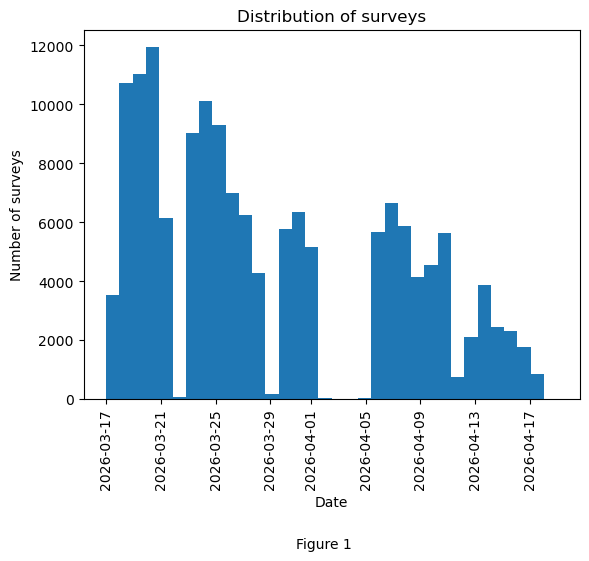

In [ ]:
%run time_frame.py

### General distributions

On the following section, the general distributions of the vectors that comprise the dataset can be seen.

In [ ]:
#%run dispersion.py

| Dataset                   | Variable                                                        |   Minimum |   Maximum |   Range |   P25 |   P75 |   IQR |   Variance |   Std Dev |
|:--------------------------|:----------------------------------------------------------------|----------:|----------:|--------:|------:|------:|------:|-----------:|----------:|
| women_priority_group      | female_head_of_household                                        |         0 |         1 |       1 |     0 |     0 |     0 |       0.1  |      0.31 |
| women_priority_group      | areas_at_risk_for_women                                         |         1 |         6 |       5 |     1 |     5 |     4 |       3.67 |      1.91 |
| women_priority_group      | women_security_violence                                         |         0 |         1 |       1 |     0 |     0 |     0 |       0.02 |      0.15 |
| youth_priority_group      | youth_work_study                                                |         0 |         1 |       1 |     0 |     0 |     0 |       0.01 |      0.1  |
| youth_priority_group      | areas_at_risk_for_youth                                         |         1 |         6 |       5 |     1 |     5 |     4 |       3.71 |      1.93 |
| youth_priority_group      | youth_security_violence                                         |         0 |         1 |       1 |     0 |     0 |     0 |       0    |      0.05 |
| indigenous_priority_group | indigenous_community_risk                                       |         0 |         1 |       1 |     0 |     1 |     1 |       0.22 |      0.47 |
| indigenous_priority_group | indigenous_security_violence                                    |         0 |         1 |       1 |     0 |     0 |     0 |       0    |      0.02 |
| indigenous_priority_group | indigenous_security_risk_zones                                  |         1 |         5 |       4 |     1 |     5 |     4 |       2.62 |      1.62 |
| security                  | sports_center_sacurity_level                                    |         0 |         3 |       3 |     2 |     3 |     1 |       0.48 |      0.69 |
| security                  | gyms_security_level                                             |         1 |         3 |       2 |     2 |     3 |     1 |       0.29 |      0.54 |
| security                  | shelter_security_level                                          |         1 |         3 |       2 |     2 |     3 |     1 |       0.4  |      0.63 |
| dwelling                  | years_of_residence                                               |         0 |       150 |     150 |    15 |    48 |    33 |     379.99 |     19.49 |
| dwelling                  | dwelling_type                                                   |         1 |         4 |       3 |     2 |     4 |     2 |       0.85 |      0.92 |
| dwelling                  | tenure_type                                                     |         1 |         4 |       3 |     3 |     3 |     0 |       0.33 |      0.57 |
| dwelling                  | overcrowding                                                    |         0 |         1 |       1 |     0 |     1 |     1 |       0.2  |      0.45 |
| dwelling                  | number_of_bedrooms                                              |         1 |        21 |      20 |     2 |     2 |     0 |       0.84 |      0.92 |
| demographics              | age                                                             |         0 |       105 |     105 |    32 |    60 |    28 |     339.69 |     18.43 |
| demographics              | age_group                                                       |         1 |         5 |       4 |     4 |     4 |     0 |       0.43 |      0.65 |
| demographics              | sex                                                             |         1 |         2 |       1 |     1 |     2 |     1 |       0.24 |      0.49 |
| demographics              | education_level                                                 |         1 |         6 |       5 |     3 |     4 |     1 |       1.01 |      1    |
| demographics              | occupation_category                                             |         1 |        31 |      30 |     6 |    31 |    25 |     154.32 |     12.42 |
| demographics              | marital_status                                                  |         1 |         5 |       4 |     1 |     3 |     2 |       1.64 |      1.28 |
| service_equipment         | panic_buttons_used                                              |         0 |         1 |       1 |     0 |     0 |     0 |       0.06 |      0.24 |
| service_equipment         | shelter_type                                                    |         1 |         2 |       1 |     1 |     1 |     0 |       0.15 |      0.38 |
| service_equipment         | shelter_facility_condition                                      |         1 |         3 |       2 |     2 |     3 |     1 |       0.38 |      0.61 |
| service_equipment         | shelter_adequate_services                                       |         0 |         1 |       1 |     1 |     1 |     0 |       0.13 |      0.36 |
| service_equipment         | shelter_travel_time                                             |         1 |        50 |      49 |     5 |    15 |    10 |      34.07 |      5.84 |
| service_equipment         | sports_center_adequate_services                                 |         0 |         1 |       1 |     1 |     1 |     0 |       0.17 |      0.41 |
| service_equipment         | gyms_adequate_services                                          |         0 |         1 |       1 |     1 |     1 |     0 |       0.07 |      0.27 |
| culture                   | festivities_name                                                |         1 |         9 |       8 |     4 |     7 |     3 |       4.4  |      2.1  |
| culture                   | festivities_time                                                |         1 |        13 |      12 |     4 |    10 |     6 |      11.98 |      3.46 |
| household_composition     | number_of_people                                                |         1 |        20 |      19 |     2 |     5 |     3 |       6.65 |      2.58 |
| household_composition     | companion_animal                                                |         0 |        54 |      54 |     0 |     1 |     1 |       2.6  |      1.61 |
| household_composition     | working_minors                                                  |         0 |         1 |       1 |     0 |     0 |     0 |       0.01 |      0.12 |
| household_composition     | number_of_working_minors                                        |         0 |        15 |      15 |     0 |     0 |     0 |       0.03 |      0.16 |
| household_composition     | working_people_over_65                                          |         0 |         1 |       1 |     0 |     0 |     0 |       0.05 |      0.23 |
| education_for_minors      | minors_not_studying                                            |         0 |        12 |      12 |     0 |     0 |     0 |       0.04 |      0.2  |
| education_for_minors      | reason_for_not_studying                                         |         1 |        12 |      11 |     2 |     4 |     2 |       1.83 |      1.35 |
| education_for_minors      | other_reason_not_studying                                       |         1 |         8 |       7 |     1 |     7 |     6 |       8.14 |      2.85 |
| services                  | water_access                                                    |         0 |         1 |       1 |     1 |     1 |     0 |       0.04 |      0.2  |
| services                  | water_frequency                                                 |         0 |         4 |       4 |     3 |     4 |     1 |       0.56 |      0.75 |
| services                  | water_access_method                                             |         1 |         5 |       4 |     4 |     4 |     0 |       0.39 |      0.62 |
| services                  | water_service_perception                                        |         1 |         5 |       4 |     3 |     4 |     1 |       0.57 |      0.75 |
| services                  | electricity_access                                              |         0 |         1 |       1 |     1 |     1 |     0 |       0.03 |      0.18 |
| services                  | electricity_type                                                |         0 |         2 |       2 |     2 |     2 |     0 |       0.09 |      0.3  |
| services                  | electricity_perception                                          |         1 |         5 |       4 |     4 |     4 |     0 |       0.38 |      0.62 |
| services                  | gas_access                                                      |         0 |         1 |       1 |     1 |     1 |     0 |       0.04 |      0.2  |
| services                  | gas_connection_type                                             |         0 |         4 |       4 |     1 |     1 |     0 |       0.47 |      0.69 |
| services                  | gas_perception                                                  |         1 |         5 |       4 |     4 |     4 |     0 |       0.37 |      0.61 |
| services                  | drainage_access                                                 |         0 |         1 |       1 |     1 |     1 |     0 |       0.09 |      0.3  |
| services                  | drainage_failure_frequency                                      |         0 |         5 |       5 |     2 |     3 |     1 |       1.45 |      1.21 |
| services                  | waste_collection_frequency                                      |         1 |         5 |       4 |     4 |     5 |     1 |       0.76 |      0.87 |
| risk                      | main_source_of_employment_and_geological_vulnerability          |         0 |         3 |       3 |     2 |     2 |     0 |       0.49 |      0.7  |
| risk                      | main_source_of_employment_and_hydrometeorological_vulnerability |         0 |         3 |       3 |     2 |     2 |     0 |       0.55 |      0.74 |
| risk                      | precipitation_risk                                              |         1 |         4 |       3 |     1 |     3 |     2 |       1.06 |      1.03 |
| risk                      | flood_risk                                                      |         1 |         5 |       4 |     2 |     5 |     3 |       2.71 |      1.65 |
| risk                      | intensity_recurrence_waterlogging                               |         1 |         5 |       4 |     1 |     1 |     0 |       0.13 |      0.37 |
| risk                      | thunderstorm_risk                                               |         1 |         5 |       4 |     2 |     4 |     2 |       1.64 |      1.28 |
| risk                      | hail_risk                                                       |         1 |         5 |       4 |     2 |     4 |     2 |       1.88 |      1.37 |
| risk                      | maximum_temperature_risk                                        |         1 |         3 |       2 |     2 |     3 |     1 |       0.25 |      0.5  |
| risk                      | minimum_temperature_risk                                        |         1 |         5 |       4 |     1 |     3 |     2 |       1.63 |      1.28 |
| risk                      | snowfall_risk                                                   |         1 |         4 |       3 |     1 |     1 |     0 |       0.19 |      0.44 |
| risk                      | slope_susceptibility_risk                                       |         1 |         5 |       4 |     1 |     1 |     0 |       0.62 |      0.79 |
| risk                      | social_vulnerability                                            |         1 |         5 |       4 |     3 |     4 |     1 |       0.83 |      0.91 |
| risk                      | social_vulnerability_to_fracturing                              |         1 |         5 |       4 |     3 |     4 |     1 |       0.83 |      0.91 |
| risk                      | seismic_risk                                                    |         1 |         3 |       2 |     1 |     3 |     2 |       0.84 |      0.92 |
| risk                      | hazard_risk_index                                                  |         1 |         5 |       4 |     2 |     5 |     3 |       2.17 |      1.47 |
| social_identity           | belongs_to_native_community                                     |         0 |         1 |       1 |     0 |     0 |     0 |       0.02 |      0.13 |
| social_identity           | which_native_language                                           |         1 |        20 |      19 |     7 |    20 |    13 |      41.82 |      6.47 |
| vulnerability             | type_of_disability                                              |         1 |         8 |       7 |     6 |     8 |     2 |       2.25 |      1.5  |
| vulnerability             | motor_disability                                                |         0 |         0 |       0 |     0 |     0 |     0 |       0    |      0    |
| vulnerability             | depression_and_anxiety_symptoms                                 |         0 |         1 |       1 |     0 |     0 |     0 |       0.04 |      0.19 |
| socioeconomic             | monthly_income                                                  |         2 |         4 |       2 |     2 |     3 |     1 |       0.29 |      0.54 |
| socioeconomic             | source_income                                                   |         1 |         3 |       2 |     1 |     1 |     0 |       0.36 |      0.6  |
| socioeconomic             | has_a_job                                                       |         0 |         1 |       1 |     0 |     1 |     1 |       0.25 |      0.5  |
| caregivin                 | performs_caregiving_duties                                      |         0 |         0 |       0 |     0 |     0 |     0 |       0    |      0    |
| community                 | frequency_of_community_participation                            |         0 |         2 |       2 |     0 |     2 |     2 |       0.61 |      0.78 |
| community                 | there_were_neighborhood_activities_over_the_last_year           |         0 |         1 |       1 |     0 |     0 |     0 |       0.14 |      0.37 |
| community                 | participated_in_neighborhood_activities                         |         0 |         1 |       1 |     0 |     1 |     1 |       0.24 |      0.49 |
| community                 | would_you_like_to_participate_in_neighborhood_activities        |         0 |         1 |       1 |     0 |     0 |     0 |       0.11 |      0.33 |
| community                 | feels_part_of_the_community                                     |         0 |         1 |       1 |     0 |     1 |     1 |       0.24 |      0.49 |
| technology                | has_smartphone                                                  |         1 |         1 |       0 |     1 |     1 |     0 |       0    |      0    |
| transportation_means      | public_transport_used                                           |         5 |         5 |       0 |     5 |     5 |     0 |       0    |      0    |

## Exploratory analysis

### Principal Component Analysis

The dataset allows the performance of dimensionality reduction analysis like the Principal Component Analysis. As an example, the dataset vectors, were separated into thematic clusters from the households and individuals datasets and a PCA run is reported (Full results can be consulted in Annex).

### Principal Dimensions Identified Through PCA Summary

| Domain | PC1 | PC2 | PC3 | Variance Explained by PC1–PC3 (%) |
|----------|----------|----------|----------|----------:|
| Environmental Hazards | Geological Hazard Exposure | Social–Climatic Vulnerability | Extreme Weather Events | 59.09 |
| Basic Services | Service Access | Service Quality | Service Reliability | 57.53 |
| Community Infrastructure | Sports Facilities | Gym Infraestructure Quality | Panic Button Usage | 83.82 |
| Household Vulnerability | Household Overcrowding | Housing Stability | Child Vulnerability | 55.62 |
| Socioeconomic Conditions | Age Structure | Socioeconomic Position | Care Burden | 61.63 |
| Social Integration | Participation Opportunities | Community Attachment | Participation Intensity | 62.68 |
| Individual Vulnerability | General Vulnerability | Disability vs Mental Health | N/P | 100.00 |

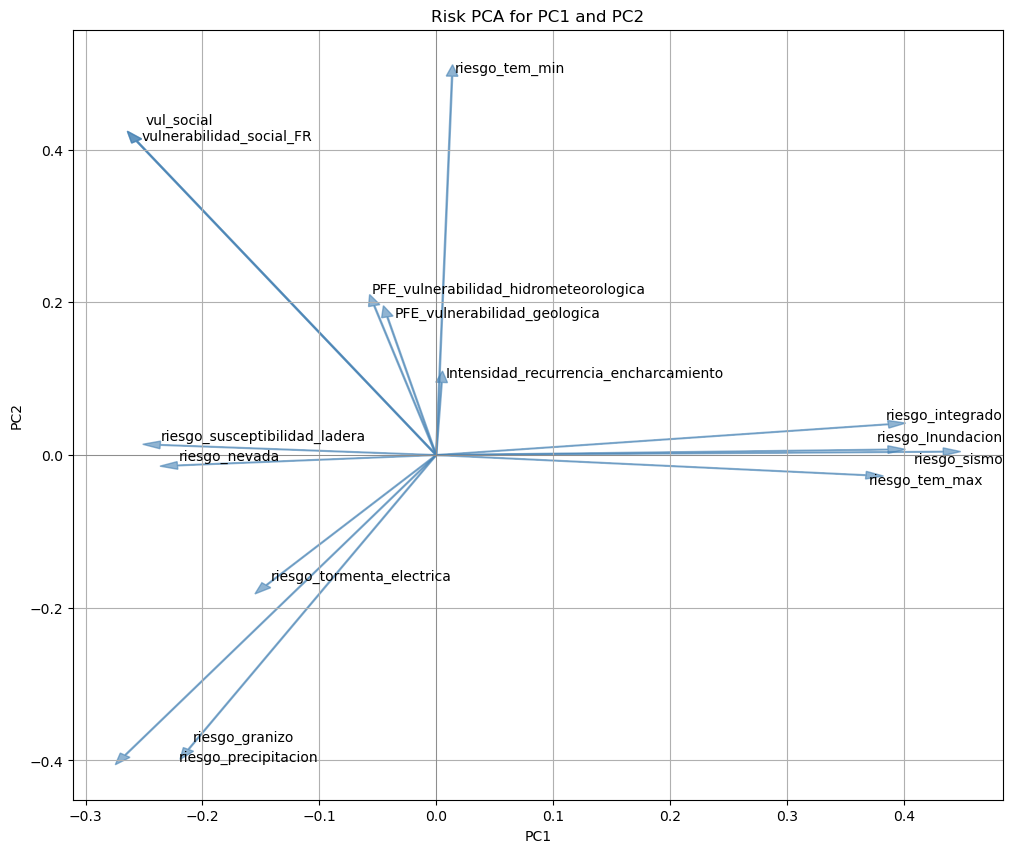

In [ ]:
%run pca.py

### Interpretation

The results suggests that vulnerability is multidimensional and develops around two different scales, the household scale drived by environmental exposure, infraestructure quality, access to services and housing conditions, and individual scale around socioeconomic position, social integration and disabilities and mental health.

### Hazards distributions

The datasets enriched with hazard distributions, enable the posibility to evaluate territorial exposure as well as severity prevalence.

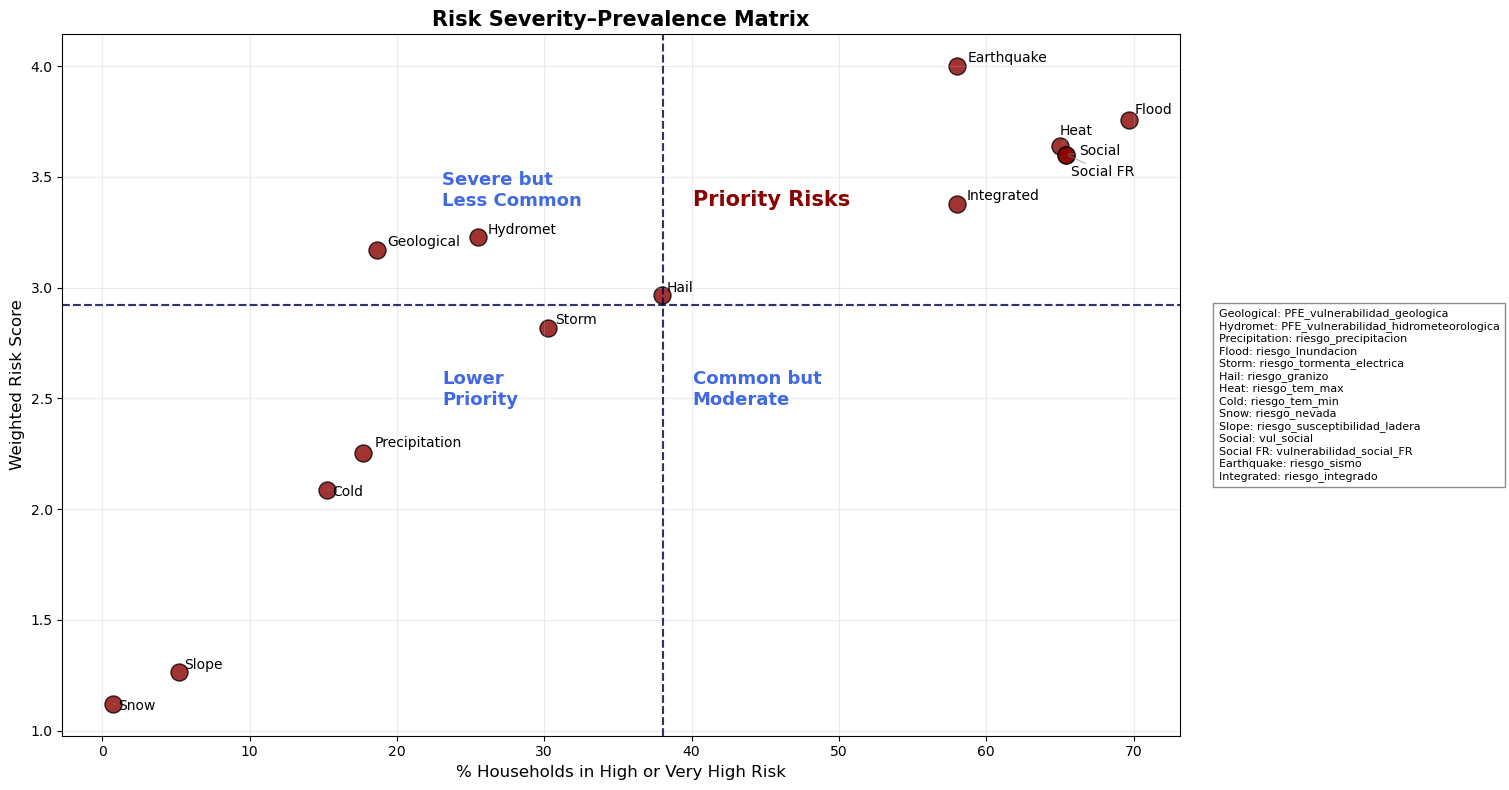

In [ ]:
%run risk_distribution.py

# Geospatial vizualization of highly exposed households areas

The dataset can be used to create risk reduction strategies through prioritization of territories through exposure and territorial vulnerability aligning each of the 62 fragility areas ("polígonos").

![grafica_tableau.jpg](attachment:862f8abf-2d5c-470a-a715-14336cbb2afe.jpg)

# Household evaluation strategy

To prioritize intervention areas, the dataset was enriched through a risk matrix methodology, integrating the Social Vulnerability Index with the Hazard Risk Index. This approach enabled the classification of territories according to their combined levels of social vulnerability and exposure to hazards. Using the resulting risk categories, relevant households areas can be identified and prioritized for inclusion in territorial strategies, including flooding, earthquakes, and landslides.

# Composition of relevant indexes

- Social Vulnerability Index: The Territorial Vulnerability Index (IVT) consists of 12 indicators ranging from 0 to 100 that compare Mexico City's 23 Territories of Peace and Equality based on socioeconomic and security-related deprivations, classifying them into four levels: Critical, High, Medium, and Low.
  
- Hazard Risk Index: The hazard risk index was developed using methodologies such as CENAPRED’s “Guide on Minimum Content for the Preparation of the National Risk Atlas” and SEDATU’s “Basis for Standardization in the Preparation of Risk Atlas” (BEEAR).

Futher information can be found in the Annex section.


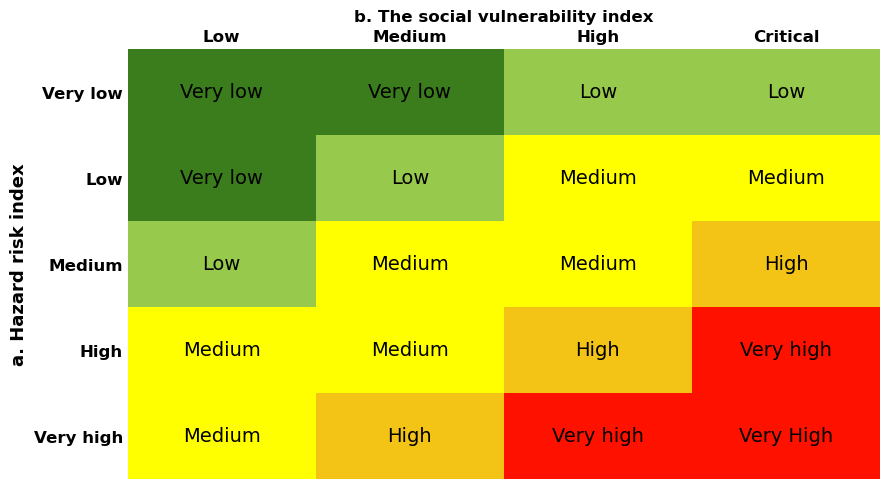

In [ ]:
%run risk_vulnerability_index.py

# Example of a segmented territory

The following image shows the territory of Tepito and Morelos.

![IVT_mas_Hazart risk index.png](attachment:d003121a-81ac-4ad5-8251-507e6ea3bdc7.png)

# Relational Analysis

The dataset vectors can be examined through both linear and nonlinear analyses. As an example, a multiple linear regression model was estimated and compared using the variables most strongly correlated with the Environmental Hazards principal component PC1. This model explained 30.08% of the variance in risk exposure (adjusted R² = 0.143; p < 0.001).

For the nonlinear analysis, a Random Forest regression model was estimated, yielding an R² = 0.075, a value substantially lower than that obtained with the multiple linear regression model (R² = 0.143). These results suggest that the relationships between Environmental Hazard PC1 and the selected predictors are primarily captured through linear structures, and that more complex nonlinear models are not optimal for predictive interpretation.

### Multiple Linear Regression Predicting Environmental Hazard PC1

| Variable | Coefficient | p-value | VIF | Interpretation |
|-----------|-----------:|---------:|----:|----------------|
| Drenaje Access | 0.637 | <0.001 | 1.12 | Strong positive association |
| Garbage Collection Frequency | 0.328 | <0.001 | 1.29 | Strong positive association |
| Water Service Frequency | 0.301 | <0.001 | 1.33 | Strong positive association |
| Overcrowding | -0.146 | <0.001 | 1.24 | Strong negative association |
| Monthly Income | 0.064 | <0.001 | 1.04 | Weak positive association |
| Educational Attainment | 0.106 | <0.001 | 1.17 | Moderate positive association |
| Household Size | -0.083 | <0.001 | 1.24 | Weak negative association |
| Years of Residence | -0.064 | <0.001 | 1.37 | Moderate negative association |
| Age | 0.056 | <0.001 | 1.49 | Very weak positive association |

**Model statistics**

| Statistic | Value |
|------------|------:|
| Observations | 63,993 |
| R² | 0.143 |
| Adjusted R² | 0.143 |
| F-statistic | 1282 |
| Model p-value | <0.001 |

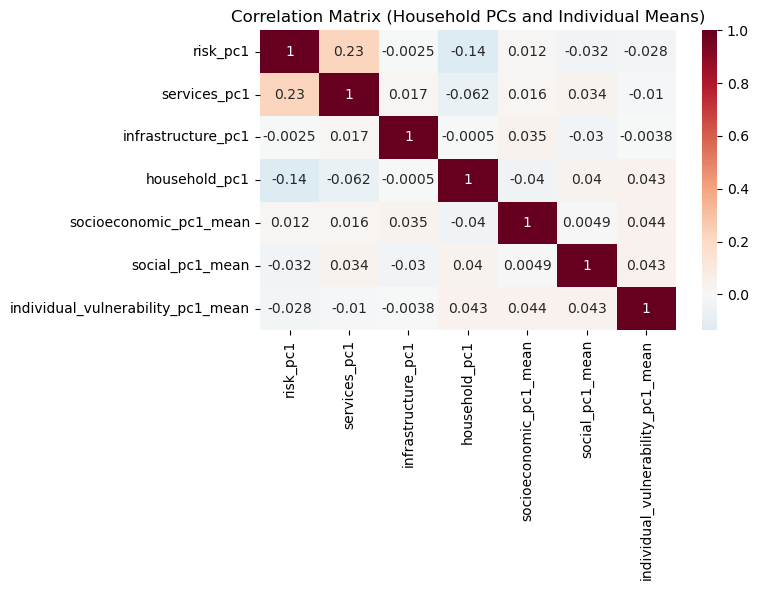

In [ ]:
%run correlation.py

R² = 0.075
RMSE = 1.980


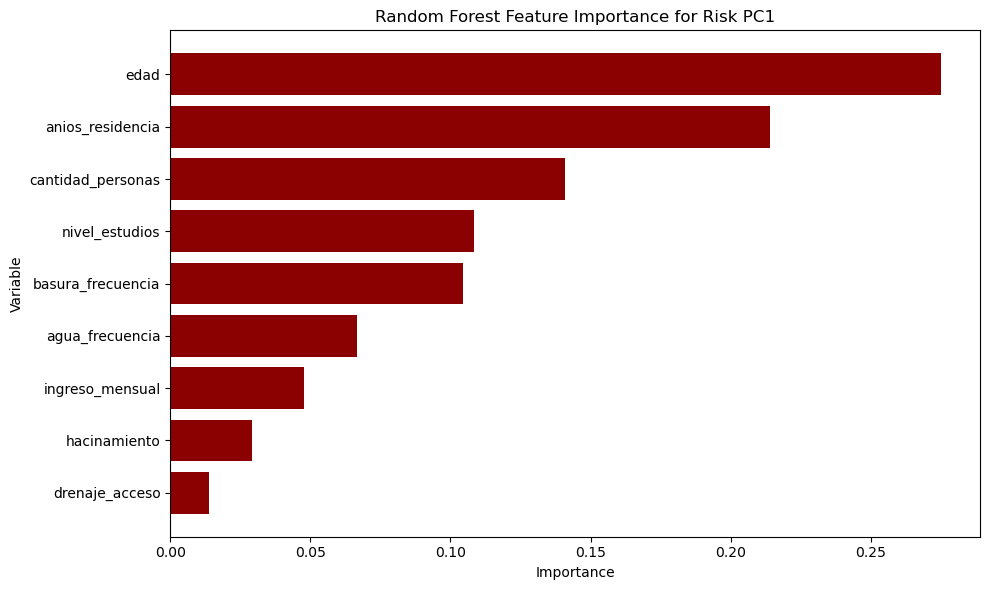

In [ ]:
%run random-forest.py

# Household Criticality and Intersectionality variables as finetuning for decision making

Through the creation of a household criticality and a intersectionality index (see in Annex), it is posible to identify areas with specialy vulnerable households (critical sample size) that requires attention, for example through the use of heat maps.

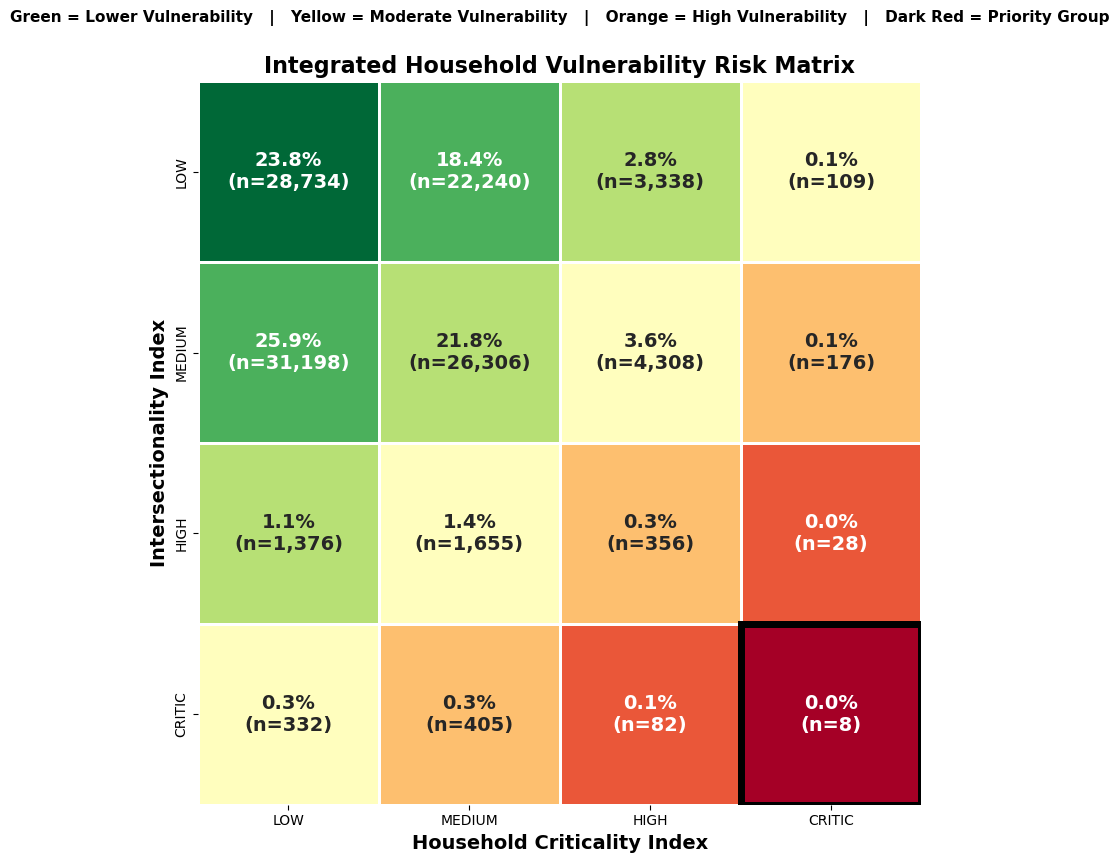

In [ ]:
%run critical_sample_size.py

![map_heat_household.jpg](attachment:175880bf-5f85-4ff4-9a33-18c913fab83b.jpg)

# Machine learning ready dataset

The datasets are prepared for the use of machine learning algoriths as K-neighbors or Support Vector Machine (SVC), making it useful for generating insights on relationships between vectors. As an example, the decision surface and accuracy of two different algorithms are shown. The SVC has been itered 100 times and validated through a Monte Carlo analysis.  

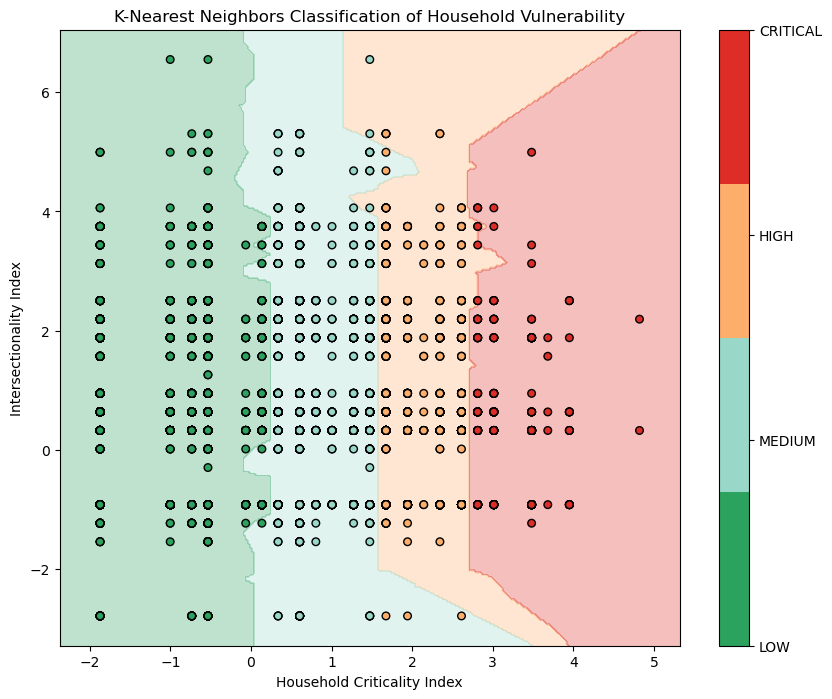

In [ ]:
%run decision_surface.py

In [ ]:
#%run svc-short.py

## High Enviromental Hazard Exposure (PC1)

*Accuracy:* 0.304,
*AUC:* 0.556

| Clase        | Precision | Recall | F1-score | Support |
|:-------------|:---------:|:------:|:--------:|:-------:|
| 0             | 0.33      | 0.53   | 0.41     | 9135    |
| 1             | 0.00      | 0.00   | 0.00     | 9615    |
| 2             | 0.27      | 0.24   | 0.26     | 8536    |
| 3             | 0.29      | 0.46   | 0.36     | 8910    |
| *Accuracy*  |           |        | *0.30* | 36196   |
| *Macro avg* | 0.22      | 0.31   | 0.26     | 36196   |
| *Weighted avg* | 0.22   | 0.30   | 0.25     | 36196   |

![multiclassSVM.jpg](attachment:85ed0358-ec81-470b-86b3-66ebe51a10c3.jpg)

![graficamontecarlo.jpg](attachment:a47d5750-1506-4d16-968f-58c6dee39adc.jpg)

# Closure

The relevance of the datasets presented in this study lies not only in the rigorous cleansing process to which they were subjected, but also in the development of two strategic indexes. These indexes enable the precise identification and prioritization of households and individuals in conditions of heightened vulnerability residing in fragile territories of Mexico City.

At present, no comparable information of this kind exists. Consequently, these datasets provide value for the design of evidence-based public policies aimed at benefiting citizens. Moreover, they constitute a fundamental tool for advancing the analysis of the sociodemographic and territorial characteristics of populations inhabiting these type of areas, offering relevant insights for scientific research and informed decision-making in disaster risk reduction.

# Annex

# Territorial Vulnerability Index (IVT)

The Territorial Vulnerability Index (IVT) was generated to describe the situation of each of the 23 territories, which are areas with a high incidence of crime, violence, lack of opportunities and marginalization. The indicators are calculated from the percentage of households that report the condition, reflecting the relative importance adding up to 1.00 (100%).
Normalization was taken to a common scale in a range from 0 to 100 where 0 corresponds to the lowest value and 100 to the highest value. Then multiply by its weight and add up the results.

General formula:

<div align=center>

$IVT_t = \frac{S_t - S_{min}}{S_{max} - S_{min}} \times 100$  where  $S_t = \sum_{v=1}^{12} w_v z_{t,v}$
</div>

| Term | Meaning |
|------|---------|
| IVT_t | Final value of the index for territory t, on a scale from 0 to 100. |
| z_t,v | Indicator v of territory t, already taken to the common scale from 0 to 100. |
| w_v | Weight of indicator v, according to the value of each indicator. |
s_t | Weighted sum of all indicators. |
| s_mín, s_máx | Lowest and highest preliminary score, where the lowest is 0 and the highest is 100. |


The result is divided into four categories:

| Category | Index Range | Reading |
|----------|-------------|---------|
| Critical | More than 75 | Maximum concentration of deficiencies of the whole. |
| High | 50 to 75 | Shortcomings above all. |
| Medium | 25 to 50 | Intermediate situation. |
| Low | 0 to 25 | Lower relative accumulation of deprivations. |

# Hazard Risk Index

The hazard risk index was developed using methodologies such as CENAPRED’s “Guide on Minimum Content for the Preparation of the National Risk Atlas” and SEDATU’s “Basis for Standardization in the Preparation of Risk Atlases” (BEEAR).

## 1. Geological and Hydrometeorological Indicators.

### Geological Indicator

Regarding slope instability, a joint analysis was conducted using CENAPRED’s “National Map of Slope Instability Susceptibility” and Basic Geostatistical Areas (AGEBs). This resulted in the “Map of Slope Instability Susceptibility by AGEB” (SGIRPC), classifying slope instability into the following categories: Very Low, Low, Medium, High, and Very High.

Separately, regarding seismic hazard, the Medium, High, and Very High categories from the “Mexico City Geotechnical Zoning Map” were assigned at the AGEB level, resulting in the “Seismic Hazard Map”.

By considering the highest hazard value between the geological phenomena of slope instability and seismic hazard, the “Geological Hazard Indicator” was determined for each AGEB, thereby establishing the “Geological Indicator”, classified into Highest Value, High Value, and Medium Value.

### Hydrometeorological Indicator

Data from active climatological stations with over 20 years of records were used to obtain the maximum daily value reported each year. Using the “AX” program developed by Dr. Jiménez (CENAPRED, 2015), the following probability functions—common in hydrology—were fitted: Normal, Lognormal, Gumbel, Exponential, Gamma, and Double Gumbel.

This process was carried out for each station. Subsequently, spatial interpolation was performed to generate a raster map covering Mexico City, and finally, a hazard level was assigned to each AGEB (Basic Geostatistical Area) based on a weighting method.

A similar procedure was followed for the hydrometeorological phenomena of maximum and minimum temperatures.

For hail and thunderstorms, the number of days of annual occurrence was taken into account. For snowfall, the hazard was characterized based on altitude. Finally, for flooding, the analysis utilized CONAGUA’s flood-proneness indicator for a 5-year return period, calculating the percentage of flood-prone area within each AGEB.

To generate the Hydrometeorological Indicator, the results for all hydrometeorological phenomena were aggregated for each AGEB.

Finally, a quantitative value is assigned to the Hazard Levels used to categorize all the phenomena:


<div align="center">

| Hazard Level | Value |
|--------------|-------|
| Very High    | 1     |
| High         | 0.8   |
| Medium       | 0.6   |
| Low          | 0.4   |
| Very Low     | 0.2   |

</div>



## 2. Fatalities and Damage Costs (in millions)

Additionally, information regarding fatalities caused by natural phenomena in Mexico City was compiled using data from:


*	SOCIOECONOMIC IMPACT OF DISASTERS DATABASE 2000–2017 (CENAPRED).
*	DATASET: GENERAL MORTALITY 1990–2017 (INEGI).
*	CHARACTERISTICS OF THE SOCIOECONOMIC IMPACT OF MAJOR DISASTERS IN MEXICO (1980–1999) (CENAPRED).


This yielded the total number of fatalities associated with each of the phenomena comprising the Geological Indicator and the Hydrometeorological Indicator.

Damage costs (in millions) caused by each phenomenon were also considered, using:

*	SOCIOECONOMIC IMPACT OF DISASTERS DATABASE 2000–2017 (CENAPRED).
*	CHARACTERISTICS OF THE SOCIOECONOMIC IMPACT OF MAJOR DISASTERS IN MEXICO (1980–1999) (CENAPRED).
*	FORCE MEXICO 2018 (FUERZA MEXICO 2018.)


This yields an annual total derived from the costs generated by each phenomenon.

Once the total data on fatalities and damage costs (in millions) are obtained, a Fatality Hazard Indicator is first generated using the following equation:

Indicator = Number of Fatalities × Hazard Level

A result is obtained for each phenomenon, and these results are summed to generate the Fatality Hazard Indicator.

Next, the same procedure is performed to generate the Hazard Indicator based on damage costs in millions of pesos.

Indicator = Damage Costs (Millions of Pesos) × Hazard Level

A result is obtained for each phenomenon, and these results are summed to generate the Hazard Indicator for Damage Costs (M$).

## 3. Integration of Final Information

Finally, the Fatality Hazard Indicator and the Damage Hazard Indicator are summed to obtain the SGIRPC Hazard Indicator, which is categorized into five classifications: Highest Value, High Value, Medium Value, Low Value, and Very Low Value.

<div align="center">

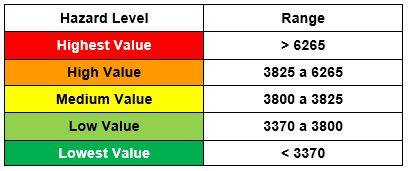


# IVT Index + Hazard Index

To reclassify the hazards identified in the Risk Atlas, a numerical value from 1 to 5 was assigned to each qualitative category, as follows:

Very High = 5

High = 4

Medium = 3

Low = 2

Very Low = 1

For the Territorial Vulnerability Index, only the qualitative categories were used to align the concepts in this study with those employed by the Secretariat for Citizen Participation and Attention namely Critical, High, Medium, and Low which were also assigned numerical values, as follows:

Critical = 40

High = 30

Medium = 20

Low = 10

Subsequently, a matrix was created by cross-referencing both sets of numerical criteria using the sum of the values, resulting in the following:


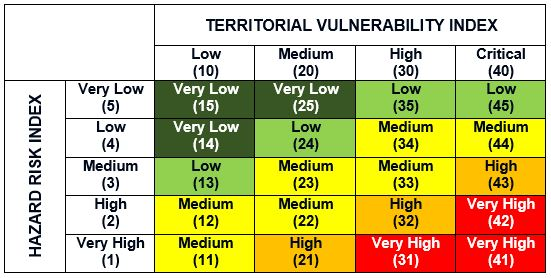


# PCA results by thematical cluster

# Environmental Hazards

## PC1 – Geological Hazard Exposure

PC1 ≈

0.432 (seismic_risk)
* +0.385 (flood_risk)
* +0.384 (hazard_risk_index)
* +0.367 (maximum_temperature_risk )
* −0.262 (precipitation_risk)
* −0.256 (social_vulnerability_to_fracturing)
* −0.256 (social_vulnerability)
* −0.236 (slope_susceptibility_risk)
* −0.221 (snowfall_risk)
* −0.210 (hail_risk)

---

## PC2 – Social–Climatic Vulnerability

PC2 ≈

0.507 (minimum_temperature_risk )
* +0.418 (social_vulnerability_to_fracturing)
* +0.418 (social_vulnerability)
* −0.401 (precipitation_risk)
* -0.398 (hail_risk)

---

## PC3 – Extreme Weather Events

PC3 ≈

0.627 (thunderstorm_risk)
* +0.391 (hail_risk)
* +0.311 (flood_risk)
* +0.282 (social_vulnerability)
* +0.282 (social_vulnerability_to_fracturing)
* −0.241 (snowfall_risk)

---

# Basic Services

## PC1 – Access to Essential Services

PC1 ≈

0.466 (electricity_access)
* +0.462 (drainage_access)
* +0.447 (water_access)
* +0.438 (gas_access )

---

## PC2 – Service Quality and Satisfaction

PC2 ≈

0.483 (water_service_perception)
* +0.449 (electricity_perception)
* +0.400 (gas_perception)
* +0.344 (water_frequency)
* +0.300 (waste_collection_frequency)

---

## PC3 – Service Reliability

PC3 ≈

0.557 (water_frequency)
* +0.498 (waste_collection_frequency)
* −0.459 (gas_perception)
* −0.371 (electricity_perception)

---

# Community Infrastructure

## PC1 – Sports Facility Quality

PC1 ≈

0.660 (sports_center_sacurity_level)
* +0.657 (sports_center_adequate_services)

---

## PC2 – Gym Infrastructure Quality

PC2 ≈

0.663 (gyms_adequate_services)
* +0.650 (gyms_security_level)

---

## PC3 – Panic Button Usage

PC3 ≈

0.995 (panic_buttons_used)

---

# Household Vulnerability

## PC1 – Household Crowding and Dependency

PC1 ≈

0.619 (number_of_people)
* +0.616 (overcrowding)
* +0.344 (minors_not_studying)
* +0.310 (number_of_working_minors)

---

## PC2 – Housing Stability

PC2 ≈

0.720 (number_of_bedrooms)
* +0.428 (years_of_residence)
* −0.380 (overcrowding)

---

## PC3 – Child Vulnerability

PC3 ≈

0.629 (number_of_working_minors)
* +0.575 (minors_not_studying)
* −0.377 (number_of_people)
* −0.271 (overcrowding)

---

# Socioeconomic Conditions

## PC1 – Age and Life-Cycle Structure

PC1 ≈

0.663 (age_group)
* +0.656 (age)
* −0.326 (education_level)

---

## PC2 – Socioeconomic Position

PC2 ≈

0.609 (monthly_income )
* +0.551 (has_a_job)
* +0.415 (education_level)

---

## PC3 – Gendered Care Burden

PC3 ≈

0.735 (performs_caregiving_duties)
* −0.657 (sex)

---

# Social Integration

## PC1 – Participation Opportunities

PC1 ≈

0.691 (there_were_neighborhood_activities_over_the_last_year)
* −0.673 (participated_in_neighborhood_activities)

---

## PC2 – Community Attachment

PC2 ≈

0.644 (would_you_like_to_participate_in_neighborhood_activities)
* +0.560 (feels_part_of_the_community)
* +0.360 (frequency_of_community_participation)

---

## PC3 – Participation Intensity

PC3 ≈

0.791 (frequency_of_community_participation)
* −0.591 (feels_part_of_the_community)

---

# Individual Vulnerability

## PC1 – General Vulnerability

PC1 ≈

0.707 (motor_disability)
* +0.707 (depression_and_anxiety_symptoms)

---

## PC2 – Disability and Mental Health

PC2 ≈

0.707 (depression_and_anxiety_symptoms)
* −0.707 (motor_disability)

# Calculation Report for the Weighting and Integration of Indexes

Principal Component Analysis made it possible to identify the vectors that concentrate the greatest variability within the structure of our risk-related data. In addition to this analysis, variables of interest were selected, oriented toward both disaster risk and intersectionality positioning. Based on the integration of the statistical analysis and thematic relevance, the selected variables were structured into two dimensions for the calculation of two new indices:

| Index | Variables / Factors Evaluated |
|---|---|
| Household Criticality Index | • Presence of older adults (60 years or older)<br>• Low income<br>• Persons with disabilities<br>• Overcrowding conditions<br>• Lack of basic public services<br>• Deficient or absent waste collection system |
| Intersectionality Index | • Prevalence of depression and anxiety conditions<br>• Belonging to an Indigenous community or being a speaker of an Indigenous language<br>• Female heads of household and/or caregiving roles<br>• Belonging to the LGBTTTIQ+ community<br>• Sense of belonging to the locality<br>• Women who identify unsafe spaces or perceive violence |


In order to differentiate the relative relevance of these sociodemographic vectors that condition vulnerability to risk, a weighting procedure was implemented through inter-expert validation. This approach made it possible to determine differentiated weights based on the technical and operational experience of specialists from 30 institutions across the three levels of government.
Data collection was carried out using a digital questionnaire in Google Forms, obtaining a final sample of n = 111 (responses). The instrument required participants to rank the vectors of each index on an ordinal scale of 1 to 6, where 1 represents the lowest priority and 6 the highest priority in generating vulnerability.
For the weighting procedure, descriptive statistics were used, calculating the mean and standard deviation (x̄ ± s) of the scores assigned to each variable. The results of this procedure were supported by the poverty and vulnerability measurement criteria of CONEVAL (2025), together with the Social Policy and Civil Protection Guidelines of Mexico City (2026).

## Household Criticality Index

| Weight | Vector |
|---|---|
| 6 | Low income |
| 6 | Persons with disabilities |
| 5 | Presence of older adults (60 years or older) |
| 5 | Overcrowding conditions |
| 4 | Lack of basic public services |
| 4 | Deficient or absent waste collection system |

## Intersectionality Index

| Weight | Vector |
|---|---|
| 6 | Prevalence of depression and anxiety conditions |
| 6 | Women who identify unsafe spaces or perceive violence |
| 5 | Female heads of household and/or caregiving roles |
| 5 | Belonging to an Indigenous community or being a speaker of an Indigenous language |
| 4 | Belonging to the LGBTTTIQ+ community |
| 4 | Sense of belonging to the locality |




The final integration of the vectors for each index was calculated through the weighted sum of the binary vulnerability vectors, multiplied by their respective weight derived from the inter-expert analysis. To ensure comparability as an index, the final result is normalized by dividing it by the total sum of the assigned weights, yielding a continuous range strictly bounded between 0 and 1.


$I = \frac{\sum_{i=1}^{k} w_i \cdot x_i}{\sum_{i=1}^{k} w_i}$

- **I**: Value of the weighted index.
- **wᵢ**: Weight attributed to indicator i (determined by the mean of expert judgment, x̄ᵢ).
- **xᵢ**: Binary indicator of presence (1) or absence (0) of the vulnerability factor.
- **k**: Total number of variables that make up the index (k = 6).

For the stratification of the Household Criticality Index and the Intersectionality Index into four attention categories (LOW, MEDIUM, HIGH, and CRITICAL), segmentation by quartiles applied to the distributed unique values was chosen, in order to ensure that the CRITICAL category truly corresponds to those households with the highest-vulnerability conditions.

| Category | Index Range |
|---|---|
| LOW | 0.00 – 0.317 |
| MEDIUM | 0.317 – 0.500 |
| HIGH | 0.500 – 0.683 |
| CRITICAL | 0.683 – 1.00 |

# Institutional Roster of Participating Specialists

The expert panel was made up of technical and managerial staff from the following 30 institutions:

- Mexico City Secretariat of Comprehensive Risk Management and Civil Protection (SGIRPC)
- Mexico City Benito Juárez
- International Airport (AICM)
- Cuauhtémoc Borough (Alcaldía), Mexico City
- Center for Industrial Job Training (CECATI)
- National Children's Center
- Fuente de Vida Clinic
- National Intelligence Center (CNI)
- Inter-American Entertainment Corporation (COMISA)
- National Commission Against Addictions (CONASAMA)
- Federal Judicial Council (CJF)
- White Neutral Cross (Cruz Blanca Neutral)
- National System for Integral Family Development (DIF Nacional)
- Farmacia para el Bienestar
- Representative of fairground worker (Ferieros) associations
- Financiera para el Bienestar (FINABIEN)
- Mexican Social Security Institute (IMSS)
- National Institute of Statistics and Geography (INEGI)
- Local Board of Conciliation and Arbitration of Mexico City (JLCA)
- Petróleos Mexicanos (PEMEX)
- PILARES Community Education Subsystem
- Asphalt Mix Production Plant
- Mexico City Passenger Transport Network (RTP)
- Mexico City Ministry of Culture
- Ministry of Original Peoples and Neighborhoods and Resident Indigenous Communities (SEPI)
- Ministry of Wellbeing and Social Equality (SEBIEN)
- Mexico City Ministry of Tourism (SECTUR)
- National Defense Ministry (SEDENA)
- Ministry of Comprehensive Water Management (SEGIAGUA)
- Secretariat of the Navy (SEMAR)
- Mexico City Electric Transport Service (STE)
- Ministry of Infrastructure, Communications and Transportation (SICT)
- XEIPN Channel Eleven (National Polytechnic Institute)

# References

- CONEVAL. (2025). Multidimensional measurement of poverty in Mexico 2024. https://www.coneval.org.mx/Medicion/Paginas/PobrezaInicio.aspx

- Consejo de Evaluación de la Ciudad de México. (2026). Guidelines for the internal evaluation of social and social equality programs. Government of Mexico City. https://www.evalua.cdmx.gob.mx/

- Secretariat for Comprehensive Risk Management and Civil Protection, Sub-directorate for Natural and Anthropogenic Phenomena. (n.d.). Indicators of Hazard, Vulnerability, and Exposure at the AGEB Level [File PDF]. Government of Mexico City.

- Secretariat of Citizen Attention and Participation, Undersecretariat of Territories of Peace and Equality. (2026, July 26). Descriptive note: Territorial Vulnerability Index (IVT). How it is built and how it is read · Situational Diagnosis for Peace. Government of Mexico City.

- Viveros Vigoya, M. (2023). Intersectionality: Decolonial and Community Turn. CLACSO; Transnational Institute.

